# Stock Price Prediction — EDA

understand data quality, structure and any patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

## 1. Load data

In [2]:
price_df = pd.read_csv('price.csv', parse_dates=['date'])
news_df = pd.read_csv('news.csv', parse_dates=['datetime'])

print(f"Price data: {price_df.shape[0]:,} rows × {price_df.shape[1]} columns")
print(f"News data:  {news_df.shape[0]:,} rows × {news_df.shape[1]} columns")

Price data: 1,687 rows × 7 columns
News data:  4,440 rows × 4 columns


## 2. Price data exploration

In [6]:
# data types
print(price_df.dtypes)
print(f"\nDate range: {price_df['date'].min().date()} → {price_df['date'].max().date()}")
print(f"Tickers:    {sorted(price_df['ticker'].unique())}")

date      datetime64[ns]
ticker            object
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

Date range: 2023-11-13 → 2024-10-28
Tickers:    ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


In [8]:
# trading days per ticker
print(price_df.groupby('ticker')['date'].count().to_string())

ticker
AAPL     241
AMZN     241
GOOGL    241
META     241
MSFT     241
NVDA     241
TSLA     241


In [10]:
# missing values
print(price_df.isnull().sum())

date      0
ticker    0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


no missing data

In [11]:
# descriptive statistics
price_df[['open', 'high', 'low', 'close', 'volume']].describe().round(2)

,open,high,low,close,volume
count,1687.00,1687.00,1687.00,1687.00,1.687000e+03
mean,245.20,248.03,242.28,245.26,9.613876e+07
std,134.58,135.78,133.25,134.54,1.442287e+08
min,45.47,46.08,45.01,45.50,5.467500e+06
25%,158.19,160.53,156.54,159.06,2.076580e+07
50%,187.36,189.28,185.42,187.43,3.934310e+07
75%,371.49,374.44,368.85,372.86,8.306055e+07
max,598.22,602.95,589.96,595.94,1.142269e+09


Data is right skewed since the mean is higher than the median. Middle spread, 50% of the data lies in the 25th and 75th percentile.

2.1 Closing price trends

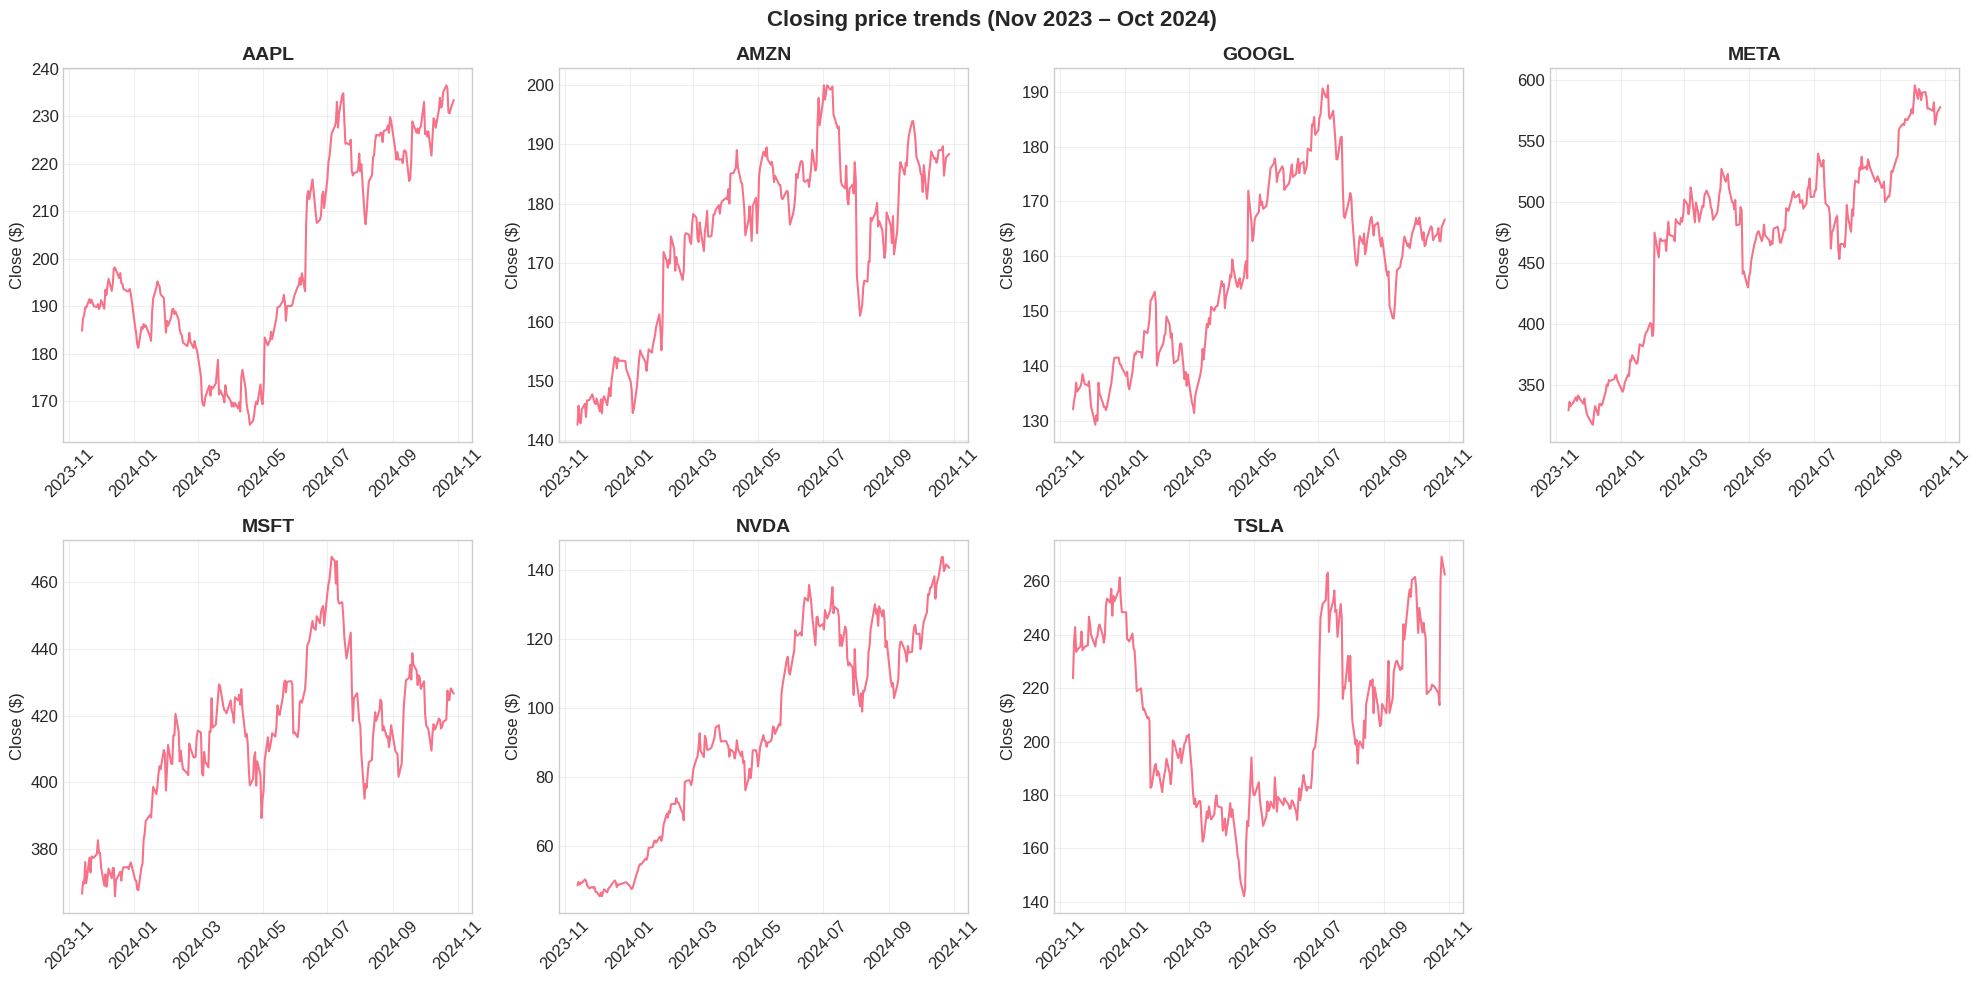

In [15]:
tickers = sorted(price_df['ticker'].unique())

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    data = price_df[price_df['ticker'] == ticker].sort_values('date')
    axes[i].plot(data['date'], data['close'], linewidth=1.5)
    axes[i].set_title(ticker, fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Close ($)')
    axes[i].grid(True, alpha=0.3)

axes[7].set_visible(False)
plt.suptitle('Closing price trends (Nov 2023 – Oct 2024)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

General growth with a local dip around april 2024 before correcting. TSLA shows high volatility unlike the rest. Almost all show typical cyclical growth patterns.

## 2.2 Daily returns distribution

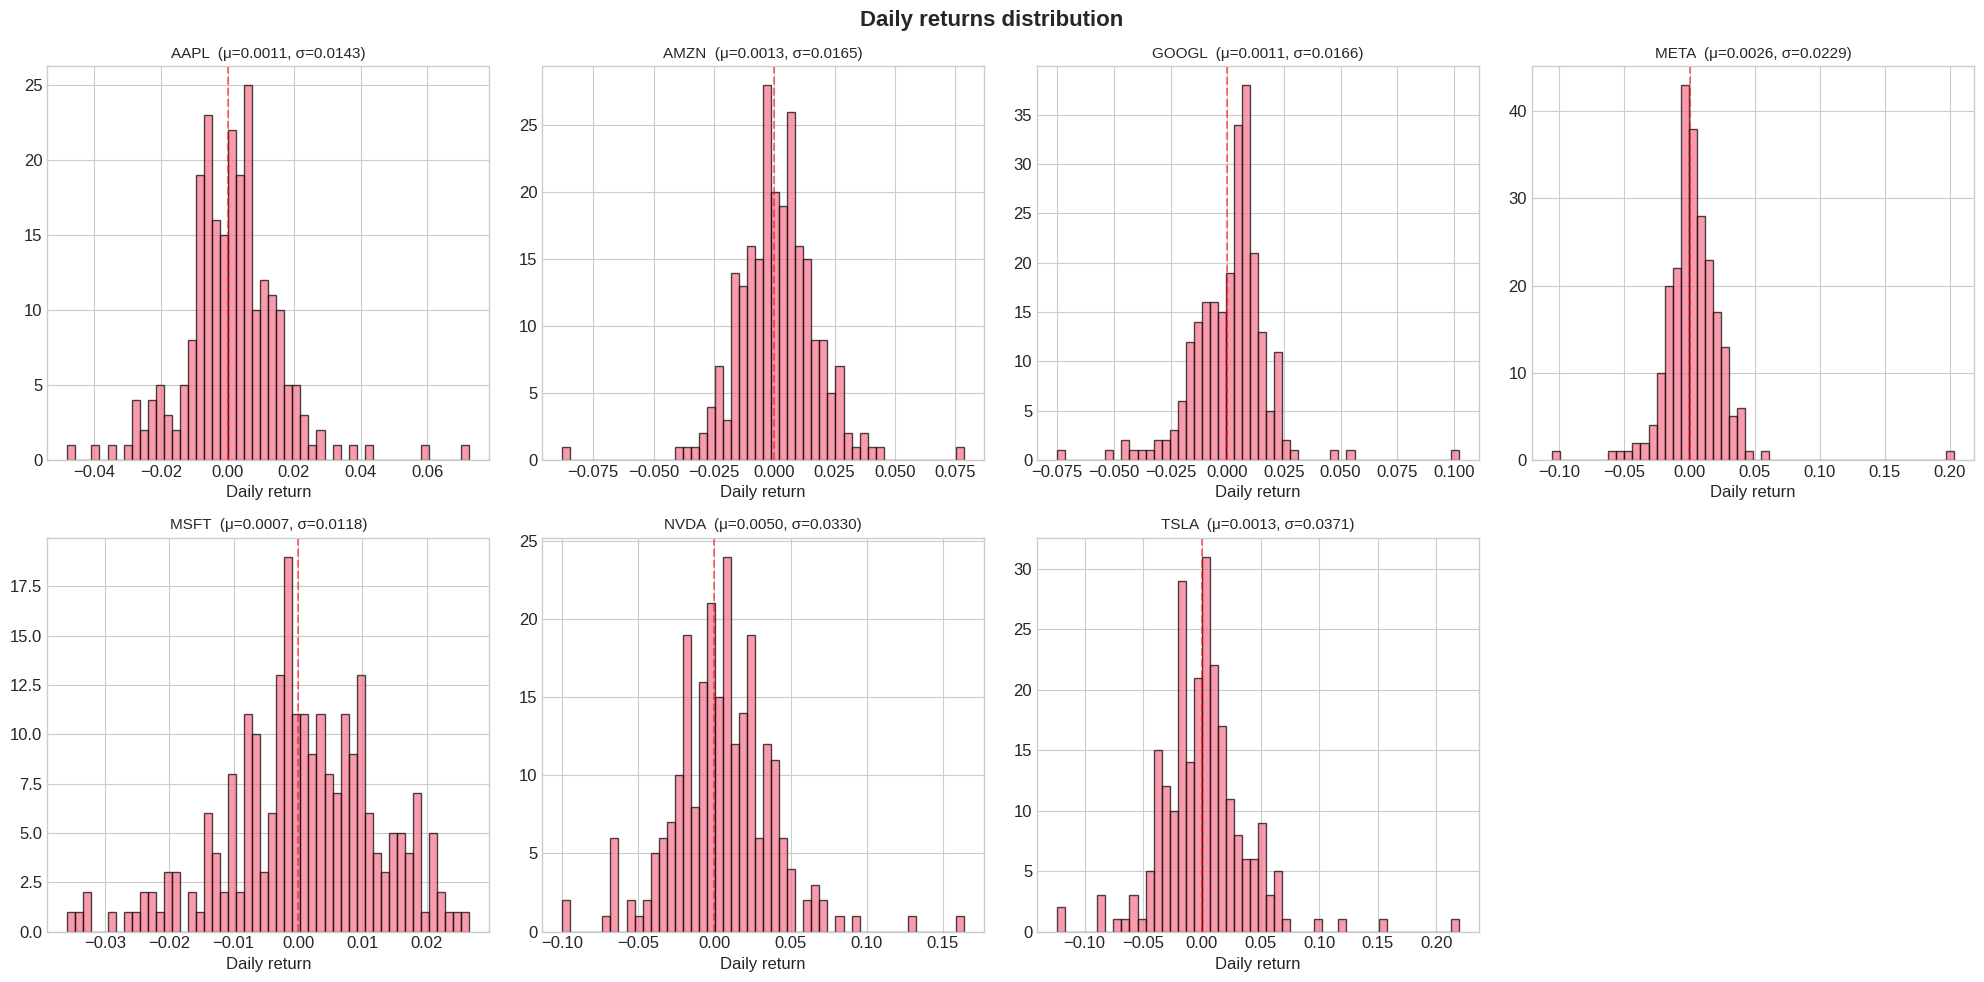

In [16]:
# compute daily returns per ticker
price_df = price_df.sort_values(['ticker', 'date'])
price_df['daily_return'] = price_df.groupby('ticker')['close'].pct_change()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    returns = price_df.loc[price_df['ticker'] == ticker, 'daily_return'].dropna()
    axes[i].hist(returns, bins=50, edgecolor='black', alpha=0.7)
    axes[i].axvline(x=0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(
        f'{ticker}  (μ={returns.mean():.4f}, σ={returns.std():.4f})',
        fontsize=11
    )
    axes[i].set_xlabel('Daily return')

axes[7].set_visible(False)
plt.suptitle('Daily returns distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

positive daily returns in general with NVDA leading the group. MSFT has the lowest volatility with the tighest dristribution. Even though the distributions aproximate a normal one, the fat tails with outliers might prove predicting not so straight forward.